# Joint Energy-Based Model (JEM) Pipeline Execution (Chunked)

This notebook demonstrates the end-to-end execution of the Tabular JEM architecture for the Home Credit Default Risk dataset using the **memory-bounded chunked training pipeline**.

It covers:
1. Data Export (Chunked)
2. Streaming Scaler Fit & Chunked Autoencoder Pre-Training
3. Chunked Latent Z Generation
4. JEM Latent Training (Iterable Dataset)
5. Diagnostics & Visualizations
6. Model Persistence for Inference
7. Inference and Submission

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import numpy as np
import polars as pl
import torch
from IPython.display import Image, display

# Ensure the 'src' module can be imported
workspace_dir = os.path.abspath("..")
sys.path.append(workspace_dir)
os.chdir(workspace_dir)  # Important to make relative paths match pipeline scripts!

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Phase 0: Data Export (Chunked)
We run the polars data pipeline to export the processed features into numbered Parquet chunks instead of a single giant file to avoid OOM errors.

In [13]:
import shutil

from src.data.config import DataPipelineConfig
from src.data.pipeline import run_pipeline

# Clean up previous runs for pristine execution
for d in ["data/processed/chunks", "data/processed/latent_chunks", "models/artifacts"]:
    shutil.rmtree(d, ignore_errors=True)

cfg = DataPipelineConfig(
    data_dir="data/raw/home-credit-credit-risk-model-stability.zip",
    sample_ratio=0.5,
    cache_dir=".cache",
    artifact_dir="models/artifacts",
    chunk_size=150000,
    chunked_export=True,
)

df_rebuilt = run_pipeline(
    config=cfg,
    depth_0_tables=["train_static_0", "train_static_cb_0"],
    depth_1_tables=[
        "train_person_1",
        "train_deposit",
        "train_debitcard",
        "train_other",
    ],
    depth_2_tables=[],
)

print(f"Dynamically Rebuilt Data Shape: {df_rebuilt.shape}")

2026-02-28 23:14:45,297 [INFO] --- Starting Data Pipeline Run (TRAINING Mode) ---
2026-02-28 23:14:45,297 [INFO] Extracting matching 'train_'/'test_' parquets from data/raw/home-credit-credit-risk-model-stability.zip to .cache
2026-02-28 23:14:45,298 [INFO] Successfully extracted 0 matching files.
2026-02-28 23:14:45,299 [INFO] Loading Base Table: train_base
2026-02-28 23:14:45,299 [INFO] Scanning table with wildcard globbing: .cache/train_base*.parquet
2026-02-28 23:14:45,302 [INFO] Collecting case_id and target columns to calculate stratified split...


2026-02-28 23:14:45,337 [INFO] Splitting case_ids by target value and sampling 50.0% in each group...
2026-02-28 23:14:45,370 [INFO] Retained 763329 records after stratified sampling.
2026-02-28 23:14:45,371 [INFO] Processing Depth-1 Table: train_person_1
2026-02-28 23:14:45,371 [INFO] Scanning table with wildcard globbing: .cache/train_person_1*.parquet
2026-02-28 23:14:45,373 [INFO] Processing Depth-1 Table: train_deposit
2026-02-28 23:14:45,373 [INFO] Scanning table with wildcard globbing: .cache/train_deposit*.parquet
2026-02-28 23:14:45,375 [INFO] Processing Depth-1 Table: train_debitcard
2026-02-28 23:14:45,375 [INFO] Scanning table with wildcard globbing: .cache/train_debitcard*.parquet
2026-02-28 23:14:45,376 [INFO] Processing Depth-1 Table: train_other
2026-02-28 23:14:45,377 [INFO] Scanning table with wildcard globbing: .cache/train_other*.parquet
2026-02-28 23:14:45,379 [INFO] Processing Depth-0 Table: train_static_0
2026-02-28 23:14:45,380 [INFO] Scanning table with wildcar

Dynamically Rebuilt Data Shape: (763329, 478)


## 2. Phase 1 & 2: Streaming Scaler Fit & Chunked AE Training
Next, we fit the scaler sequentially over chunks using Welford's algorithm to compute the global mean and variance, and then use the `ChunkedParquetDataset` to train the Autoencoder in a memory-bounded way.

In [15]:
import json

from torch.utils.data import DataLoader

from src.model.autoencoder.model import TabularAutoencoder
from src.model.autoencoder.train_autoencoder import _save_artifacts, weighted_mse_loss
from src.model.jem.data_utils import ChunkedParquetDataset, get_feature_cols
from src.model.jem.scaler import TorchStandardScaler

chunk_dir = Path("data/processed/chunks")
chunk_paths = sorted(chunk_dir.glob("train_chunk_*.parquet"))
feature_cols = get_feature_cols(df_rebuilt)
input_dim = len(feature_cols)

# Persist feature columns for inference
os.makedirs("models/artifacts", exist_ok=True)
with open("models/artifacts/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
print(
    f"Saved {len(feature_cols)} feature columns to models/artifacts/feature_cols.json"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using input dimension: {input_dim}")
print(f"Using device: {device}")

# Phase 1: Streaming Scaler
scaler = TorchStandardScaler(num_features=input_dim)
scaler.streaming_fit(chunk_paths, feature_cols)

# Phase 2: AE Training
latent_dim = 128
autoencoder = TabularAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

print("Starting Chunked Autoencoder Training...")
epochs_ae = 10  # Quick run for demonstration
for epoch in range(1, epochs_ae + 1):
    train_dataset = ChunkedParquetDataset(
        chunk_paths=chunk_paths,
        feature_cols=feature_cols,
        scaler=scaler,
        shuffle_buffer_size=10000,
        seed=42,
    )
    # The IterableDataset set_epoch ensures shuffling shifts across epochs
    train_dataset.set_epoch(epoch)
    train_loader = DataLoader(train_dataset, batch_size=512)

    autoencoder.train()
    total_loss = 0.0
    for batch_idx, (x_batch, _y_batch, _week_batch, weights_batch) in enumerate(
        train_loader
    ):
        x_batch = x_batch.to(device)
        weights_batch = weights_batch.to(device)

        ae_optimizer.zero_grad()
        x_recon, _ = autoencoder(x_batch)
        loss = weighted_mse_loss(x_batch, x_recon, weights_batch)
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()
    print(
        f"AE Epoch [{epoch}/{epochs_ae}] | Training Loss: {total_loss / (batch_idx + 1):.4f}"
    )

# Save artifacts
_save_artifacts(autoencoder, scaler)

Saved 474 feature columns to models/artifacts/feature_cols.json
Using input dimension: 474
Using device: cpu
Starting Chunked Autoencoder Training...
AE Epoch [1/10] | Training Loss: 0.2094
AE Epoch [2/10] | Training Loss: 0.1547
AE Epoch [3/10] | Training Loss: 0.1291
AE Epoch [4/10] | Training Loss: 0.1149
AE Epoch [5/10] | Training Loss: 0.1030
AE Epoch [6/10] | Training Loss: 0.0952
AE Epoch [7/10] | Training Loss: 0.0861
AE Epoch [8/10] | Training Loss: 0.0777
AE Epoch [9/10] | Training Loss: 0.0756


2026-02-28 23:27:31,140 [INFO] Encoder saved to data/processed/encoder.pt
2026-02-28 23:27:31,141 [INFO] Scaler saved to data/processed/scaler.pt


AE Epoch [10/10] | Training Loss: 0.0734


## 3. Phase 3: Chunked Latent Z Generation
Now we generate the latent space representations individually for each chunk. This ensures we never load the full dataset's latent representation into memory AT ONCE.

In [16]:
from src.model.autoencoder.train_autoencoder import generate_latent_chunks

latent_chunks_dir = "data/processed/latent_chunks"

print("Generating Latent Chunks...")
generate_latent_chunks(
    autoencoder=autoencoder,
    scaler=scaler,
    chunk_paths=chunk_paths,
    feature_cols=feature_cols,
    output_dir=latent_chunks_dir,
    device=device,
    batch_size=512,
)
print("Latent chunks generation complete.")

Generating Latent Chunks...


2026-02-28 23:29:56,259 [INFO] Saved data/processed/latent_chunks/latent_chunk_001.pt (shape: torch.Size([150000, 128]))
2026-02-28 23:29:57,755 [INFO] Saved data/processed/latent_chunks/latent_chunk_002.pt (shape: torch.Size([150000, 128]))
2026-02-28 23:29:58,923 [INFO] Saved data/processed/latent_chunks/latent_chunk_003.pt (shape: torch.Size([150000, 128]))
2026-02-28 23:29:59,946 [INFO] Saved data/processed/latent_chunks/latent_chunk_004.pt (shape: torch.Size([150000, 128]))
2026-02-28 23:30:01,011 [INFO] Saved data/processed/latent_chunks/latent_chunk_005.pt (shape: torch.Size([150000, 128]))
2026-02-28 23:30:01,191 [INFO] Saved data/processed/latent_chunks/latent_chunk_006.pt (shape: torch.Size([13329, 128]))


Latent chunks generation complete.


## 4. Phase 4: JEM Latent Training
We use the new `ChunkedLatentDataset` to train the Joint Energy-Based Model using the latent representations computed in the previous step.

In [ ]:
from torch.utils.data import TensorDataset

from src.model.jem.config import JEMConfig
from src.model.jem.data_utils import ChunkedLatentDataset
from src.model.jem.loss import JEMLoss
from src.model.jem.model import TabularJEM
from src.model.jem.sampler import SGLDReplayBuffer, SGLDSampler
from src.model.jem.train import evaluate_jem, train_jem_epoch

jem_config = JEMConfig(
    hidden_dims=[128, 64, 32],
    spectral_norm=True,
    sgld_steps=20,
    sgld_step_size=0.009,
    sgld_sigma=0.03,
    l2_energy_weight=1e-3,
    reinit_freq=0.05,
    shuffle_buffer_size=10000,
)

# Initialize Model, Buffer, Sampler
jem_model = TabularJEM(input_dim=latent_dim, num_classes=2, config=jem_config).to(
    device
)
buffer = SGLDReplayBuffer(buffer_size=10000, feature_dim=latent_dim)
sampler = SGLDSampler(config=jem_config)
criterion = JEMLoss(config=jem_config)
jem_optimizer = torch.optim.Adam(jem_model.parameters(), lr=1e-4, weight_decay=1e-5)

# For chunks training
latent_chunk_paths = sorted(Path(latent_chunks_dir).glob("latent_chunk_*.pt"))

# For demo, take last chunk as validation set
val_path = latent_chunk_paths[-1]
val_data = torch.load(val_path, weights_only=False)
val_dataset = TensorDataset(val_data["z"], val_data["y"], val_data["weeks"])
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

train_chunk_paths = latent_chunk_paths[:-1]
if len(train_chunk_paths) == 0:
    train_chunk_paths = latent_chunk_paths  # Fallback if only 1 chunk was created

print("Starting JEM Latent Training...")
epochs_jem = 10
history = {
    "train_loss": [],
    "val_stability": [],
    "e_real_train": [],
    "e_fake_train": [],
    "val_energies": [],
}

for epoch in range(1, epochs_jem + 1):
    train_dataset = ChunkedLatentDataset(
        chunk_paths=train_chunk_paths,
        shuffle_buffer_size=jem_config.shuffle_buffer_size,
        seed=42,
    )
    train_dataset.set_epoch(epoch)
    train_loader = DataLoader(train_dataset, batch_size=256)

    train_logs = train_jem_epoch(
        jem_model, train_loader, jem_optimizer, criterion, buffer, sampler, device
    )
    val_logs = evaluate_jem(jem_model, val_loader, device)

    history["train_loss"].append(train_logs["loss"])
    stability = val_logs["stability_result"]["stability_metric"]
    history["val_stability"].append(stability)
    history["e_real_train"].append(train_logs["gen_loss"] / 2.0)
    history["e_fake_train"].append(-train_logs["gen_loss"] / 2.0)

    if epoch == epochs_jem:
        history["val_energies"] = val_logs["energies"]
        final_val_probs = val_logs["probs"]
        final_val_y = val_logs["labels"]

    print(
        f"JEM Epoch [{epoch:02d}/{epochs_jem}] | Loss: {train_logs['loss']:.4f} | Validation Gini Stability: {stability:.4f}"
    )

Starting JEM Latent Training...
JEM Epoch [01/10] | Loss: -27.1624 | Validation Gini Stability: 0.5085
JEM Epoch [02/10] | Loss: -4.1946 | Validation Gini Stability: 0.5055
JEM Epoch [03/10] | Loss: -4.2792 | Validation Gini Stability: 0.5084


## 5. Phase 5: Diagnostics & Visualizations
Investigate specialized metrics for the JEM model.

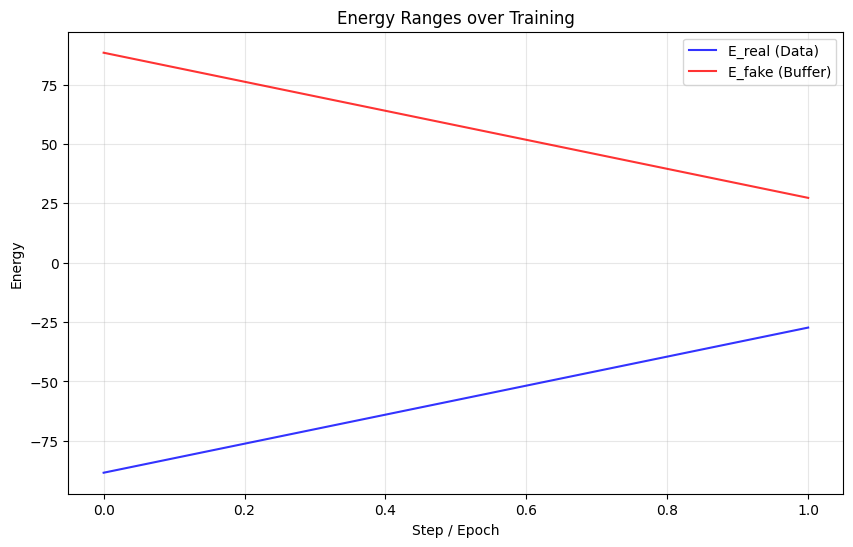

In [6]:
import os

from src.model.jem.diagnostics import JEMDiagnostics

os.makedirs("docs/assets/", exist_ok=True)

# 1. Energy Ranges over Training
JEMDiagnostics.plot_energy_ranges(
    history["e_real_train"],
    history["e_fake_train"],
    save_path="docs/assets/energy_ranges.png",
)
display(Image(filename="docs/assets/energy_ranges.png"))

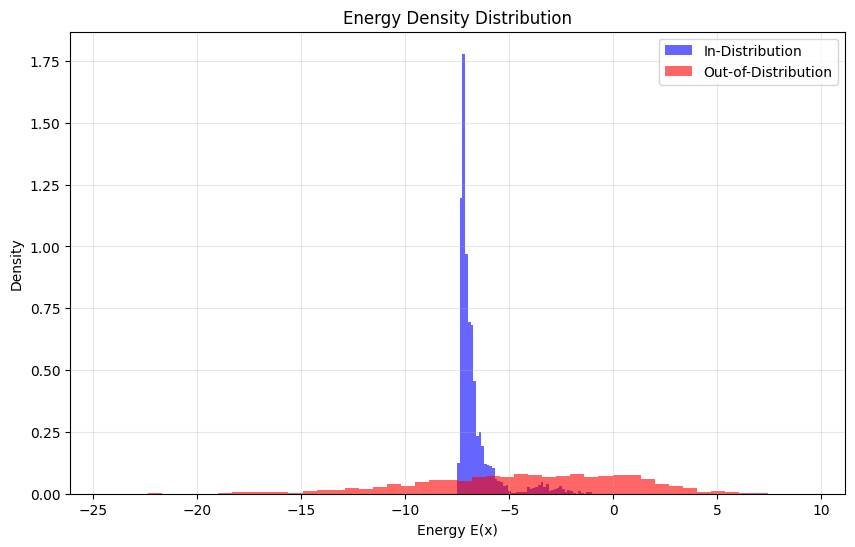

In [7]:
# 2. Energy Density Distribution
simulated_ood = []
jem_model.eval()
with torch.no_grad():
    for x_real, _, _ in val_loader:
        x_real = x_real.to(device)
        x_ood = x_real + torch.randn_like(x_real) * 10.0
        ood_energies = jem_model.compute_energy(x_ood)
        simulated_ood.append(ood_energies.cpu().numpy())

sim_ood_np = np.concatenate(simulated_ood)
JEMDiagnostics.plot_energy_density(
    history["val_energies"],
    e_out_dist=sim_ood_np,
    save_path="docs/assets/energy_density.png",
)
display(Image(filename="docs/assets/energy_density.png"))

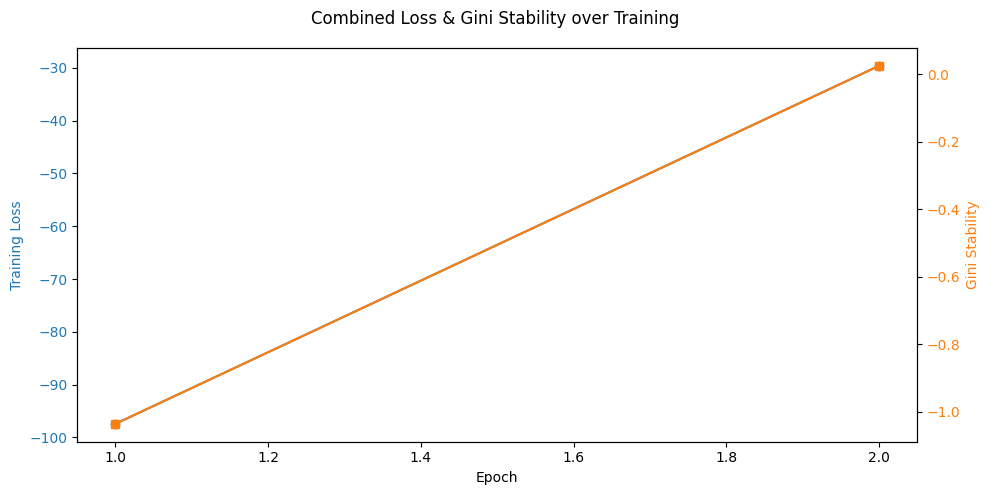

In [8]:
# 3. Combined Loss + Stability
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color="tab:blue")
ax1.plot(
    range(1, len(history["train_loss"]) + 1),
    history["train_loss"],
    "o-",
    color="tab:blue",
    label="Train Loss",
)
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Gini Stability", color="tab:orange")
ax2.plot(
    range(1, len(history["val_stability"]) + 1),
    history["val_stability"],
    "s-",
    color="tab:orange",
    label="Val Stability",
)
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle("Combined Loss & Gini Stability over Training")
fig.tight_layout()
plt.savefig("docs/assets/loss_stability.png", bbox_inches="tight")
plt.close()
display(Image(filename="docs/assets/loss_stability.png"))

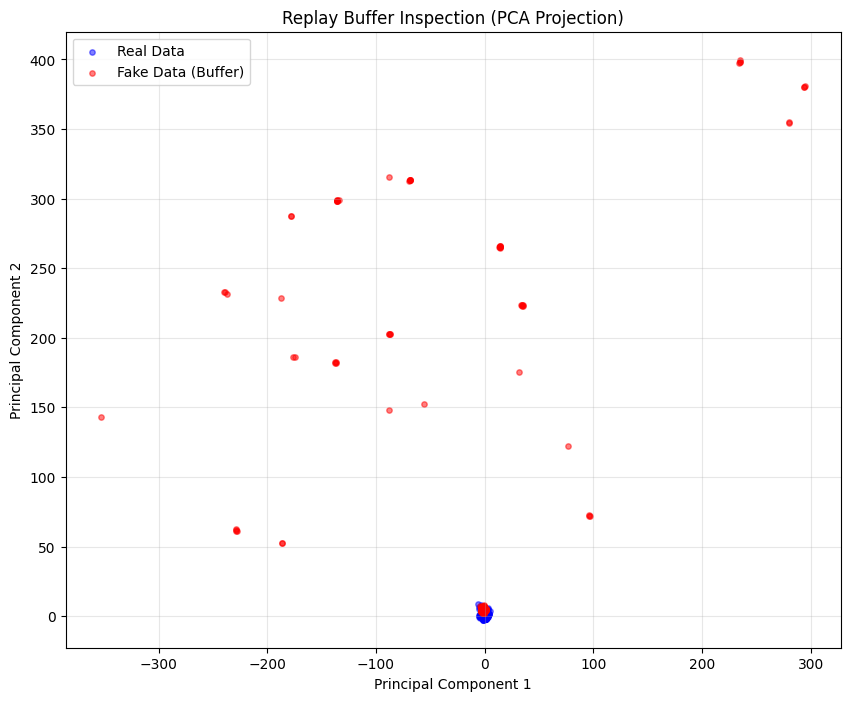

In [9]:
# 4. Replay Buffer Inspection (PCA Projection)
# Ensures the generated SGLD samples are aligned with the data manifold.
last_batch_x, _, _ = next(iter(val_loader))
JEMDiagnostics.inspect_replay_buffer(
    buffer, last_batch_x, save_path="docs/assets/buffer_inspection.png"
)
display(Image(filename="docs/assets/buffer_inspection.png"))

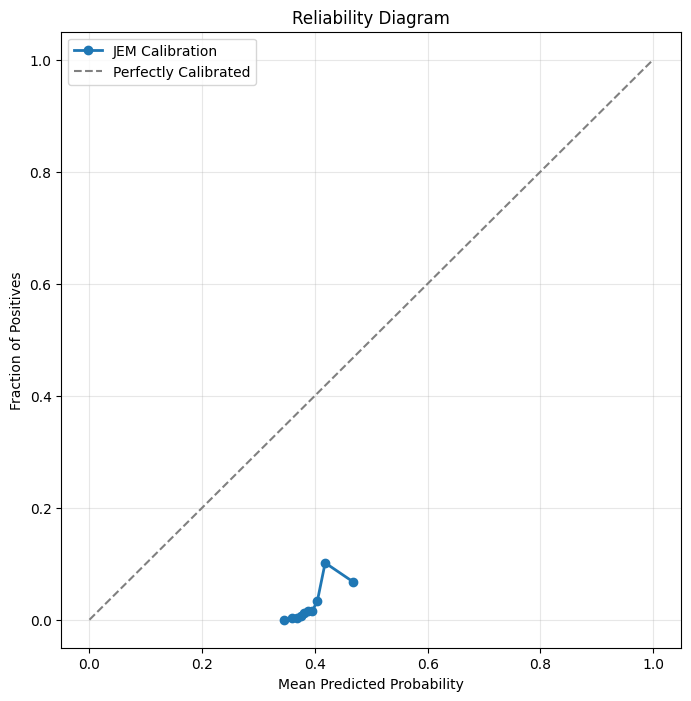

In [10]:
# 5. Reliability Diagram (Calibration)
# Checks if the JEM's predicted probabilities are well-calibrated.
JEMDiagnostics.plot_reliability_diagram(
    final_val_y, final_val_probs, save_path="docs/assets/reliability_diagram.png"
)
display(Image(filename="docs/assets/reliability_diagram.png"))

## 6. Phase 6: Model Persistence for Inference
Save the final combined LatentJEMWrapper model for standalone inference pipeline.

In [11]:
import shutil

from src.model.jem.model import LatentJEMWrapper

artifact_dir = "models/artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Package Model into wrapper
wrapper = LatentJEMWrapper(scaler, autoencoder.encoder, jem_model)
torch.save(wrapper.state_dict(), os.path.join(artifact_dir, "latent_jem_full.pt"))

# Also save scaler and encoder individually for fallback
torch.save(
    autoencoder.encoder.state_dict(), os.path.join(artifact_dir, "autoencoder.pth")
)
torch.save(
    {
        "num_features": scaler.num_features,
        "eps": getattr(scaler, "eps", 1e-8),
        "state_dict": scaler.state_dict(),
    },
    os.path.join(artifact_dir, "scaler.pth"),
)

print(f"Artifacts saved to {artifact_dir}")

Artifacts saved to models/artifacts


## 7. Inference and Submission
Final submission generation.

In [12]:
from src.data.config import DataPipelineConfig
from src.data.pipeline import run_pipeline
from src.model.jem.config import JEMConfig
from src.model.jem.data_utils import get_inference_dataloader, load_feature_cols
from src.model.jem.infer import perform_inference

test_cfg = DataPipelineConfig(
    data_dir="data/raw/home-credit-credit-risk-model-stability.zip",
    sample_ratio=1.0,
    is_inference=True,
    artifact_dir="models/artifacts",
)

test_df = run_pipeline(
    config=test_cfg,
    depth_0_tables=["train_static_0", "train_static_cb_0"],
    depth_1_tables=[
        "train_person_1",
        "train_deposit",
        "train_debitcard",
        "train_other",
    ],
    depth_2_tables=[],
)

feature_cols = load_feature_cols("models/artifacts")

# JEMConfig identical to training
jem_config = JEMConfig(artifact_dir="models/artifacts", hidden_dims=[128, 64, 32])

# Load the inference pipeline
from src.model.autoencoder.model import TabularAutoencoder

scaler_inf = TorchStandardScaler(num_features=len(feature_cols))
scaler_state = torch.load(
    os.path.join(artifact_dir, "scaler.pth"), map_location=device, weights_only=False
)
scaler_inf.load_state_dict(scaler_state["state_dict"])
scaler_inf.to(device)

ae_inf = TabularAutoencoder(input_dim=len(feature_cols), latent_dim=128)
ae_inf.encoder.load_state_dict(
    torch.load(
        os.path.join(artifact_dir, "autoencoder.pth"),
        map_location=device,
        weights_only=False,
    )
)
ae_inf.to(device)
ae_inf.eval()

jem_inf = TabularJEM(input_dim=128, num_classes=2, config=jem_config)
wrapper_state = torch.load(
    os.path.join(artifact_dir, "latent_jem_full.pt"),
    map_location=device,
    weights_only=False,
)
wrapper_inf = LatentJEMWrapper(scaler_inf, ae_inf.encoder, jem_inf)
wrapper_inf.load_state_dict(wrapper_state)
wrapper_inf.to(device)
wrapper_inf.eval()

# In some implementations load_inference_pipeline loads scaler, ae, jem individually.
# Hence we loaded them iteratively, now perform inference using the original pattern.
loader = get_inference_dataloader(test_df, feature_cols, batch_size=4096)
case_ids, probs, energies = perform_inference(
    scaler=scaler_inf,
    autoencoder=ae_inf,
    jem=jem_inf,
    loader=loader,
    device=device,
    return_energies=True,
)

submission_df = pl.DataFrame({"case_id": case_ids, "score": probs})
submission_df.write_csv("submission.csv")
print(f"Submission generated: submission.csv (Shape: {submission_df.shape})")

2026-02-28 23:14:15,832 [INFO] --- Starting Data Pipeline Run (INFERENCE Mode) ---
2026-02-28 23:14:15,832 [INFO] Extracting matching 'train_'/'test_' parquets from data/raw/home-credit-credit-risk-model-stability.zip to .cache
2026-02-28 23:14:15,835 [INFO] Successfully extracted 0 matching files.
2026-02-28 23:14:15,835 [INFO] Loading Base Table: test_base
2026-02-28 23:14:15,836 [INFO] Scanning table with wildcard globbing: .cache/test_base*.parquet
2026-02-28 23:14:15,839 [INFO] Process all case_ids for inference.
2026-02-28 23:14:15,840 [INFO] Processing Depth-1 Table: test_person_1
2026-02-28 23:14:15,841 [INFO] Scanning table with wildcard globbing: .cache/test_person_1*.parquet
2026-02-28 23:14:15,849 [INFO] Processing Depth-1 Table: test_deposit
2026-02-28 23:14:15,849 [INFO] Scanning table with wildcard globbing: .cache/test_deposit*.parquet
2026-02-28 23:14:15,852 [INFO] Processing Depth-1 Table: test_debitcard
2026-02-28 23:14:15,852 [INFO] Scanning table with wildcard glob

Submission generated: submission.csv (Shape: (10, 2))
